In [1]:
import sys
sys.path.append('../')  # Adjust the path

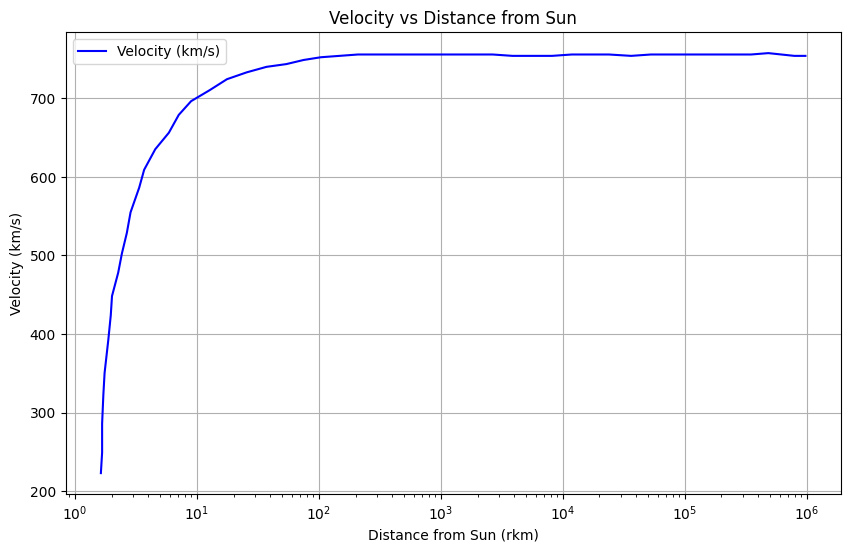

In [2]:
# read the csv file 'vel25au.csv', 1st column is rkm, 2nd column is velocity
import csv
import numpy as np
import matplotlib.pyplot as plt
rkm = []
velocity = []
with open('../vel25au.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        rkm.append(float(row[0]))
        velocity.append(float(row[1]))
rkm = np.array(rkm)
velocity = np.array(velocity)

# plot velocity vs rkm
plt.figure(figsize=(10, 6))
plt.semilogx(rkm, velocity, label='Velocity (km/s)', color='blue')
plt.xlabel('Distance from Sun (rkm)')
plt.ylabel('Velocity (km/s)')
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()
plt.show()


<Figure size 1200x800 with 0 Axes>

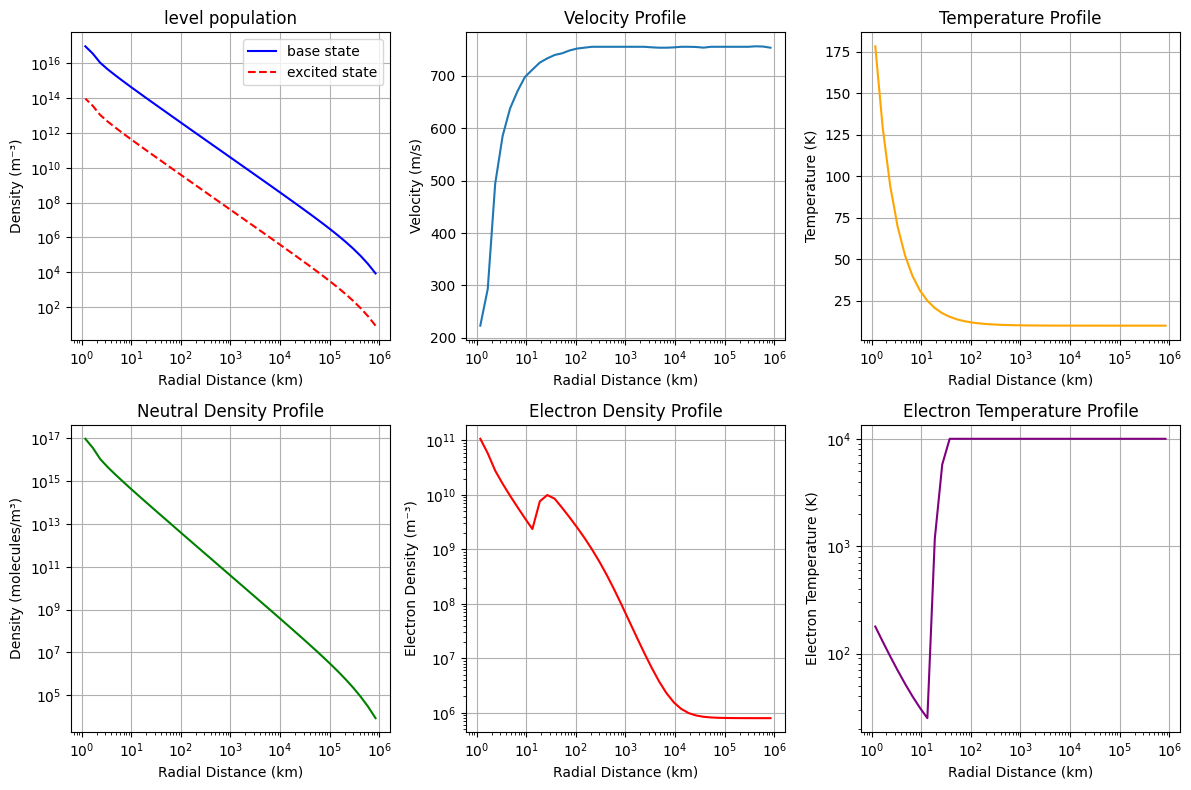

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ComaGrid import ComaGrid
from profiles import calc_density, velocity_tanh, temperature_inverse_distance, electron_biver_1997

# Radial grid: 40 layers, outermost layer at index 0 (far side)
xf = np.logspace(3, 9, 41)[::-1]           # cell faces, 41 points from 1e9 -> 1e3 m
xc = np.sqrt(xf[:-1] * xf[1:])        # geometric mean 

# Heliocentric distance (AU)
r_h = 2.5

# Velocity and temperature profiles
v0 = 720.0          # terminal velocity in m/s
c_scale = 3.5e3      # scale parameter in meters
# velocity = velocity_tanh(xc, v0=v0, c=c_scale)

# extropolate velocity from csv file
velocity = np.interp(xc, rkm*1e3, velocity)



T0 = 10.0          # reference temperature in K
temperature = temperature_inverse_distance(xc, a=10, b=1, t0=T0, r0=2000)

# Neutral density (isotropic), photo-dissociation included
# Density profile: isotropic radial outflow
# n(r) = Q / (4π r² v)
Q = 3.7e26            # production rate (molecules/s)
density = calc_density(Q, xc, velocity, r_h=2.5, model_type='isotropic', photo_dissociation=True)

# Electron density and temperature (Biver et al. 1997)
nelec, telec = electron_biver_1997(Q, r_h=2.5, r=xc, v=velocity, t_kin=temperature, t_emax=10000)


# Simple TWO-level population fractions (levels 1 IS excited)
fractions = np.zeros((xc.size, 1))
fractions[:, 0] = 1.0e-3


coma = ComaGrid(temperature, density, velocity, nelec, telec, fractions)
coma.xf = xf
coma.xc = xc

# # plot profiles, xc, VEL, TEMP, DENSITY, ELECTRON, ne, telec
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axs=axes.flatten()

# axs[0].plot(np.arange(xc.size), coma.xc * 1e-3, label='Nucleocentric distance (km)')
# axs[0].set_yscale('log')
# axs[0].set_xlabel('Grid Index (0=outermost layer)')
# axs[0].set_ylabel('Nucleocentric distance (km)')
# axs[0].set_title('Velocity Profile')
# axs[0].grid()

# level fraction at 0, and 1 level
axs[0].loglog(xc/1000, coma.density[:, 0], 'b-', label='base state')
axs[0].loglog(xc/1000, coma.density[:, 1], 'r--', label='excited state')
axs[0].set_xscale('log')
axs[0].set_xlabel('Radial Distance (km)')
axs[0].set_ylabel('Density (m⁻³)')
axs[0].set_title('level population')
axs[0].legend()
axs[0].grid()

axs[1].plot(xc/1000, velocity, label='Velocity (m/s)')
axs[1].set_xscale('log')
axs[1].set_xlabel('Radial Distance (km)')
axs[1].set_ylabel('Velocity (m/s)')
axs[1].set_title('Velocity Profile')
axs[1].grid()

axs[2].plot(xc/1000, temperature, label='Temperature (K)', color='orange')
axs[2].set_xscale('log')
axs[2].set_xlabel('Radial Distance (km)')
axs[2].set_ylabel('Temperature (K)')
axs[2].set_title('Temperature Profile')
axs[2].grid()

axs[3].loglog(xc/1000, density, label='Density (molecules/m³)', color='green')
# axs[2].set_xscale('log')
axs[3].set_xlabel('Radial Distance (km)')
axs[3].set_ylabel('Density (molecules/m³)')
axs[3].set_title('Neutral Density Profile')
axs[3].grid()

axs[4].loglog(xc/1000, coma.nelec, label='Electron Density (m⁻³)', color='red')
# axs[3].set_xscale('log')
axs[4].set_xlabel('Radial Distance (km)')
axs[4].set_ylabel('Electron Density (m⁻³)')
axs[4].set_title('Electron Density Profile')
axs[4].grid()


axs[5].loglog(xc/1000, coma.telec, label='Electron Temperature (K)', color='purple')
# axs[4].set_xscale('log')
axs[5].set_xlabel('Radial Distance (km)')
axs[5].set_ylabel('Electron Temperature (K)')
axs[5].set_title('Electron Temperature Profile')
axs[5].grid()


plt.tight_layout()
plt.show()

